# Find folders with data
1. Input data files are available in the read-only "../input/" directory
2. For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Import packages for convinient work :)

The [warnings](https://docs.python.org/3/library/warnings.html) package helps to control Warnings messeges during your analysis. Particularly, **warnings.filterwarnings('ignore')** filters all the warnings occurring during the code to be ignored

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Load the data
Let's import **pandas** package to load the data needed and use method[ pandas.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) 

In [ ]:
import pandas as pd 

train = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')
sample_submission = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv')

# Observe the numerical features

1. DataFrame function [pandas.DataFrame.head](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html) returns the first n rows for the object based on position. It is useful for quickly testing if your object has the right type of data in it

In [ ]:
train.head()

2. DataFrame method [pandas.DataFrame.info](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html) prints information about a DataFrame including the index dtype and columns, non-null values and memory usage

In [ ]:
train.info()

3. To extract Generate descriptive statistics of numeric features let's use method [pandas.DataFrame.describe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html): 

Descriptive statistics include those that summarize the central tendency, dispersion and shape of a dataset’s distribution, excluding NaN values.
Analyzes both numeric and object series, as well as DataFrame column sets of mixed data types. The output will vary depending on what is provided. Refer to the notes below for more detail.

For numeric data, the result’s index will include *count*, *mean*, *std*, *min*, *max* as well as lower, 50 and upper percentiles. By default the lower percentile is 25 and the upper percentile is 75. The 50 percentile is the same as the median.

* Mostly interesting statistics are count, mean (arithmetic mean $ \mu $), std (standard deviation $ \sigma $), min, max - so we collect their names into list **idx_list**
$$ {\displaystyle {\mu}={\frac {1}{n}}\left(\sum _{i=1}^{n}{x_{i}}\right)={\frac {x_{1}+x_{2}+\dots +x_{n}}{n}}} $$
$$ {\displaystyle \sigma ={\sqrt {{\frac {1}{N}}\sum _{i=1}^{N}(x_{i}-\mu )^{2}}}} $$
* We need to drop **SalePrice**, **Id** from **train** dataset since they are not relevant to analysis purposes (**Id** is a just a sequence for rows, **SalePrice** is a target value - we will carry out detailed research of it later). The method [pandas.DataFrame.drop](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html) is useful for such a task, we set parameter **axis = 1** to drop columns. We get **df_descr** DataFrame
* We transpose result DataFrame using [pandas.DataFrame.T](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.T.html) or [pandas.DataFrame.transpose](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.transpose.html) methods for the reflection the DataFrame over its main diagonal by writing rows as columns and vice-versa
* Then add new statistics "CV" - The [coefficient of variation](https://en.wikipedia.org/wiki/Coefficient_of_variation) (CV) is the ratio of the standard deviation to the mean. The higher the coefficient of variation, the greater the level of dispersion around the mean.If the coefficient of variation is greater than 1, it shows relatively high variability in the data sets. On the flip side, a CV lower than 1 is considered to be low-variance. The coefficient of variation ($c_{\rm {v}}$) is defined as the ratio of the standard deviation $ \sigma $ to the mean $ \mu $:
$$ c_{\rm {v}}={\frac {\sigma }{\mu }} $$
* Next we need to calculate [Pearson correlation](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) ($r_{xy}$) between target values and numeric features. $${\displaystyle r_{xy}={\frac {\sum _{i=1}^{n}(x_{i}-{\mu _{x}})(y_{i}-{\mu _{y}})}{{\sqrt {\sum _{i=1}^{n}(x_{i}-{\mu _{x}})^{2}}}{\sqrt {\sum _{i=1}^{n}(y_{i}-{\mu _{y}})^{2}}}}}}$$To do so we can use function [pandas.DataFrame.corr](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) witch computes pairwise correlation of columns, excluding NA/null values. We take only column **SalePrice** renamed to **corr** by [pandas.DataFrame.rename](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html) method from the resulting DataFrame with pairwise correlation and merge it with the core one using method[ pandas.DataFrame.merge](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html) 
![](https://upload.wikimedia.org/wikipedia/commons/thumb/3/34/Correlation_coefficient.png/800px-Correlation_coefficient.png)
* The last column in **df_descr** DataFrame is **nulls** which stands for percentage of null-values out of all values in a column. Consiquently exploit methods [pandas.DataFrame.isna](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html), [pandas.DataFrame.sum](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html) which returns number of null-values for each feature. To obtain percentage we divide on total number of rows (use function [len()](https://realpython.com/len-python-function/)) multiplied to 100.
* To make the DataFrame more "beautiful" and colorful you can take advantage of the property [DataFrame.style](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.style.html) and Class [pandas.io.formats.style.Styler](https://pandas.pydata.org/docs/reference/api/pandas.io.formats.style.Styler.html#pandas.io.formats.style.Styler) - the idea is approximately same as paint cells with different colors. In this case we use the method [pandas.io.formats.style.Styler.background_gradient ](https://pandas.pydata.org/docs/reference/api/pandas.io.formats.style.Styler.background_gradient.html#) for columns **CV**, **corr**, **nulls**.


In [ ]:
idx_list = ['count','min','max','mean', 'std']
df_descr = train.drop(['SalePrice', 'Id'], axis = 1).describe().T[idx_list]
df_descr['CV'] = df_descr['std']/df_descr['mean']
df_descr = df_descr \
       .merge(pd.DataFrame(train.drop('Id', axis = 1).corr()['SalePrice']) \
       .rename(columns={'SalePrice':'corr'}), left_index=True, right_index=True)
df_descr.merge(pd.DataFrame(train.isna().sum()/len(train)*100, columns = ['nulls']), left_index=True, right_index=True) \
       .style.background_gradient(subset = ['CV',"nulls", "corr"], 
                                  cmap = "summer_r", 
                                  vmin = 0, 
                                  vmax = 1)

As it can be found out from the table and the description some numerical features should/could be treated as categorical (ordinal, in particular, for the first three) ones:
* **MSSubClass**
* **OverallQual**
* **OverallCond**
* MoSold
* BsmtFullBath
* FullBath
* HalfBath
* KitchenAbvGr
* BedroomAbvGr
* TotRmsAbvGrd
* Fireplaces
* GarageCars

Also there is a great oppotunity to visualize a correlation matrix

1. Import neccesary libraries [matplotlib](https://matplotlib.org) and [seaborn](https://seaborn.pydata.org)
2. We use Class [matplotlib.pyplot.rcParams](https://matplotlib.org/stable/api/matplotlib_configuration_api.html#matplotlib.RcParams) to set or change the size of fiqure without using its environment
3. Use [seaborn.heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html) - it plots rectangular data as a color-encoded matrix

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rcParams['figure.figsize']=[20,16]
tc = train.corr()
sns.heatmap(tc,cmap='coolwarm');

# Visualize numerical features 

Let's observe each feature independently. Begin with histograms (described above). For a visual conviniece we migth use subplots just to see every graph in one picture. We're going to harness function [matplotlib.pyplot.subplot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot.html) in for-cycle. It allows us to add an Axes to the current figure. Then to adjust the padding between and around subplots we're going to use [matplotlib.pyplot.tight_layout](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tight_layout.html). For the purpose of displaying all open figures (subplots) there is special function [matplotlib.pyplot.show](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html)

* Draw the histogram and kernel approximation function with [seaborn.displot](https://seaborn.pydata.org/generated/seaborn.displot.html#seaborn.displot)

In [ ]:
c =1
plt.rcParams['figure.figsize']=[20,56]
for i in df_descr.index:
    plt.subplot(len(df_descr)//3, 3, c)
    sns.distplot(train[i])
    c += 1
plt.tight_layout()
plt.show()

Overwhelmenly large part of the data is distributing abnormally (skewed). Let's see these features combined with target variable SalePrice. To do so we can use [seaborn.scatterplot](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) in the same fashion before

In [ ]:
c =1
for i in df_descr.index:
    plt.subplot(len(df_descr)//3, 3, c)
    sns.scatterplot(data = train, x = i, y = "SalePrice")
    c += 1
plt.tight_layout()
plt.show()

# Dealing with non-numerical features

1. First of all we need to find all non-numeric features in a dataset. The simpliest way is to use [pandas.DataFrame.dtypes](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html), which returns a Series with the data type of each column, together with [pandas.DataFrame.columns](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html), which gives us the column labels of the DataFrame. Categorical features have data type **"object"**
2. For the purpose of convinience let's put some important information of these features to the pandas.DataFrame with columns **unique_cnt** (number of unique values), **unique_values** (pretty much comprehensible), **count** (number of non-nullable values) and **nulls** (percentage of null-values)
3. To obtain number of unique value we can use [pandas.DataFrame.nunique](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nunique.html) and for their names - [pandas.Series.unique](https://pandas.pydata.org/docs/reference/api/pandas.Series.unique.html) with a function [pandas.Series.apply](https://pandas.pydata.org/docs/reference/api/pandas.Series.apply.html) to apply str-method for each value in columns to convert null-values to string and then concatenate them using String join-method which returns a string by joining all the elements of an iterable (list, string, tuple), separated by the given separator
4. The rest of statistics are the same as calculated before
5. Visualize them with [seaborn.scatterplot](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)

In [ ]:
u_list = []
for c in train.columns[train.dtypes == 'object']:
    l_ = ", ".join(set(train[c].apply(str).unique()))
    u_list.append(l_)
df_obj = pd.DataFrame(train[train.columns[train.dtypes == 'object']].nunique()
                      , columns = ['unique_cnt'])
df_obj = df_obj.merge(pd.DataFrame(u_list, index = df_obj.index
                                   , columns = ['unique_values'])
                                   , left_index=True, right_index=True)
df_obj['count'] = train[train.columns[train.dtypes == 'object']].count()
df_obj['nulls'] = train[train.columns[train.dtypes == 'object']].isna().sum()/len(train) * 100
df_obj

In [ ]:
c =1
for i in df_obj.index:
    plt.subplot(len(df_obj)//3, 4, c)
    sns.scatterplot(data = train, x = i, y = "SalePrice")
    c += 1
plt.tight_layout()
plt.show()

# Encoding categorical features

**Categorical data** is non-numeric and often can be characterized into categories or groups. We encode categorical data numerically because math is generally done using numbers. The most popular and simplest ones are:
1. [One-Hot Encoding](https://en.wikipedia.org/wiki/One-hot)
One-hot encoding is a method of identifying whether a unique categorical value from a categorical feature is present or not.It is a group of bits among which the legal combinations of values are only those with a single high (1) bit and all the others low (0). For example, if our feature is primary color (and each row has only one primary color), one-hot encoding would represent whether the color present in each row is red, blue, or green

![](https://www.researchgate.net/publication/344409939/figure/fig1/AS:940907041918978@1601341128930/An-example-of-one-hot-encoding.png)

**Advantages**
* Determining the state has a low and constant cost of accessing one flip-flop
* Changing the state has the constant cost of accessing two flip-flops
* Easy to design and modify
* Easy to detect illegal states
* Takes advantage of an FPGA's abundant flip-flops
* Using a one-hot implementation typically allows a state machine to run at a faster clock rate than any other encoding of that state machine

**Disadvantages**
* Requires more flip-flops than other encodings, making it impractical for PAL devices
* Many of the states are illegal



2. [Label Encoding](https://www.mygreatlearning.com/blog/label-encoding-in-python/#labelencoding) and [Ordinal Encoding](https://www.scaler.com/topics/data-science/ordinal-encoding/)

**Ordinal** encoding simply assign a unique numerical value to each category. The number are given based on the order they are appeared in the dataset by default. For example, customer feedback survey data uses a Likert scale that is finite, as shown below.

![](https://d1m75rqqgidzqn.cloudfront.net/wp-data/2020/08/11155656/image-36.png)

In this case, let’s say the feedback data is collected using a five-point Likert scale. The numerical code 1, is assigned to Poor, 2 for Fair, 3 for Good, 4 for Very Good, and 5 for Excellent. We can observe that 5 is better than 4, and 5 is much better than 3. But if you look at excellent minus good, it is meaningless. 

**Label** Encoding is used to transform our dataset target variable to Numbers where each Label/class is represented by unique number. It is kind of similar to ordinal encoding however these numbers can't be ranked/ordered. From the below image, after label encoding, the numeric value is assigned to each of the categorical values. You might be wondering why the numbering is not in sequence (Top-Down), and the answer is that the numbering is assigned in alphabetical order. Delhi is assigned 0 followed by Gujarat as 1 and so on.

![](https://d1m75rqqgidzqn.cloudfront.net/wp-data/2020/08/11155757/image-37.png)

3. [Target Encoding](https://towardsdatascience.com/dealing-with-categorical-variables-by-using-target-encoder-a0f1733a4c69)

The main idea behind the **target** encoder is to encode the categories by replacing them for a measurement of the effect they might have on the target.
On a binary classifier, the simplest way to do that is by calculating the probability p(t = 1 | x = ci) in which t denotes the target, x is the input and ci is the i-th category. In Bayesian statistics, this is considered the posterior probability of t=1 given the input was the category ci.
This means we will replace the category ci for the value of the posterior probability of the target being 1 on the presence of that category.

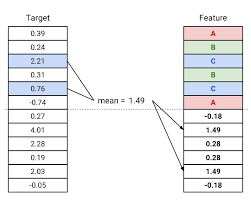


> 1. https://towardsdatascience.com/categorical-feature-encoding-547707acf4e5
> 2. https://www.mygreatlearning.com/blog/label-encoding-in-python/#labelencoding
> 3. https://towardsdatascience.com/dealing-with-categorical-variables-by-using-target-encoder-a0f1733a4c69

1. Let's split the train data on the regressors and target-variables. Typically, they are named as X and y respactively. Moreover, column **"Id"** is nothing than numerical order of rows therefore we don't need it for the futher analysis
2. Then build a custom ordinal transformer, because it is nessecery to assign exact value for a particular quality in some columns: **ExterQual**, **ExterCond**, **BsmtQual**, **BsmtCond**, **HeatingQC**, **KitchenQual**, **FireplaceQu**, **GarageQual**, **GarageCond**, **PoolQC**. Name it **CustomOrdinalTransformer**. To do this we need Class [sklearn.preprocessing.OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder). How to create a custom transformer you could find for link down below.
* Ex = Excellent -> 5
* Gd = Good -> 4
* TA = Average/Typical -> 3
* Fa = Fair -> 2
* Po = Poor -> 1
* NA = Not exist -> 0
* If Nan or not included -> -1

3. Let's create a list with name of the features aforementioned - **quality_column_list**
4. Create list of features that incompasse no more than 4 (excluded) features - **one_hot_column_list**
5. The rest of categorical features will be encoded with Target method - **target_columns_list**
6. Take 3 features from numerical one and treat them as ordinal ones - **other_columns_list**
7. Numerical features will be put into a certain list - **num_columns_list** 

> https://www.andrewvillazon.com/custom-scikit-learn-transformers/

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

class CustomOrdinalTransformer(OrdinalEncoder):
    def __init__(self, by=1, columns=None):
        self.by = by
        self.columns = columns
    
    def fit(self, X, y=None):
        return self

    def mapper(self, x):
        _dic = {'NA':0, 'Po': 1, 'Fa':2, 'TA':3, 'Gd': 4, 'Ex':5}
        return _dic.get(x, -1)
    
    def transform(self, X, y=None):
        cols_to_transform = X.columns
        if self.columns:
            cols_to_transform = self.columns
        for col in cols_to_transform:
            X[col] = X[col].apply(self.mapper)
        return X
    
X, y = train.drop(['SalePrice', 'Id'], axis = 1), train['SalePrice']

quality_column_list = [  'ExterQual', 'ExterCond'
                       , 'BsmtQual', 'BsmtCond'
                       , 'HeatingQC', 'KitchenQual'
                       , 'FireplaceQu', 'GarageQual'
                       , 'GarageCond', 'PoolQC']

one_hot_column_list = [c for c in list(df_obj[df_obj['unique_cnt'] < 4].index) if c not in quality_column_list]

target_columns_list = [c for c in list(df_obj[df_obj['unique_cnt'] >= 4].index) if c not in quality_column_list]

other_columns_list = ['MSSubClass', 'OverallQual','OverallCond']

num_columns_list = [c for c in X.columns[X.dtypes != 'object'] if c not in other_columns_list]


# Scaling numerical features

Feature Scaling is performed during the Data Preprocessing step. Also known as normalization, it is a method that is used to standardize the range of features of data. Most of the Machine Learning algorithms (for example, Linear Regression) give a better performance when numerical input variables (i.e., numerical features) are scaled to a standard range.

Feature Scaling is important as the scale of the input variables of the data can have varying scales. Python’s sklearn library provides a lot of scalers such as **MinMax** Scaler, **Standard** Scaler, and **Robust** Scaler.

1. [MinMax](https://towardsdatascience.com/everything-you-need-to-know-about-min-max-normalization-in-python-b79592732b79)

Also known as min-max scaling or min-max normalization, rescaling is the simplest method and consists in rescaling the range of features to scale the range in [0, 1] or [−1, 1]. Selecting the target range depends on the nature of the data. The general formula for a min-max of [0, 1] is given as

$$x'={\frac  {x-{\text{min}}(x)}{{\text{max}}(x)-{\text{min}}(x)}}$$

where x is an original value, x' is the normalized value

2. [Standard (Z-score Normalization)](https://medium.com/analytics-vidhya/standardscaler-and-normalization-with-code-and-graph-ba220025c054)

In machine learning, we can handle various types of data, e.g. audio signals and pixel values for image data, and this data can include multiple dimensions. Feature standardization makes the values of each feature in the data have zero-mean (when subtracting the mean in the numerator) and unit-variance. This method is widely used for normalization in many machine learning algorithms (e.g., support vector machines, logistic regression, and artificial neural networks). The general method of calculation is to determine the distribution mean and standard deviation for each feature. Next we subtract the mean from each feature. Then we divide the values (mean is already subtracted) of each feature by its standard deviation.

$$x' = \frac{x - \bar{x}}{\sigma}$$

where x is the original feature vector, $\bar{x}$ is the mean of that feature vector, and $\sigma$  is its standard deviation.

3. [Robust](https://en.wikipedia.org/wiki/Robust_measures_of_scale)

Robust Scaler algorithms scale features that are robust to outliers. The method it follows is almost similar to the MinMax Scaler but it uses the interquartile range (rather than the min-max used in MinMax Scaler). The median and scales of the data are removed by this scaling algorithm according to the quantile range.

It, thus, follows the following formula:

$$x' = \frac{x - Q_{\rm {1}}}{IQR }$$

where x is the original feature vector, $IQR = Q_{\rm {3}} - Q_{\rm {1}}$. And $Q_{\rm {1}}$ is the lower quartile (25%), $Q_{\rm {3}}$ is the upper quartile (75%). 


> https://machinelearninggeek.com/feature-scaling-minmax-standard-and-robust-scaler/


# Implement column transformation

1. To implement **numerical features** scaler we can exploit Classes from [sklearn.preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html). As aforementioned we'd like to scale the data with one of the following: [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html), [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), [RobustScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html)
2. But before embeding a scaler it is requered to impute missed/null-values. There is Class [sklearn.impute.SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) devoted to that purpose. 
3. Since imputing and scaling are requered to be in sequential fasion there is one possible convinient solution - [sklearn.pipeline.Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), it allows us equentially apply a list of transforms. The purpose of the pipeline is to assemble several steps, it enables setting parameters of the various steps using their names and the parameter. Let's name a pipeline **num_pipe** 

![](https://i.stack.imgur.com/jEULG.png)

4. Class [sklearn.compose.ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) applies transformers to columns of an array or pandas DataFrame.This estimator allows different columns or column subsets of the input to be transformed separately and the features generated by each transformer will be concatenated to form a single feature space. This is useful for heterogeneous or columnar data, to combine several feature extraction mechanisms or transformations into a single transformer.

![](https://ubc-cs.github.io/cpsc330/_images/column-transformer.png)

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_pipe = Pipeline([
     ('imputer', SimpleImputer(strategy='median'))
   , ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer([
      ('CustomOrdinalTransformer', CustomOrdinalTransformer(), quality_column_list)
    , ('OneHotEncoder', OneHotEncoder(handle_unknown='ignore'), one_hot_column_list)
    , ('TargetEncoder', TargetEncoder(), target_columns_list)
    , ('Numerical', num_pipe, num_columns_list)
    , ('OrdinalFromNumerical', SimpleImputer(strategy='constant', fill_value=-1), other_columns_list)
])

# First attemps with **linear** models

1. [Ridge Regression ](https://en.wikipedia.org/wiki/Ridge_regression#:~:text=Ridge%20regression%20is%20a%20method,econometrics%2C%20chemistry%2C%20and%20engineering.)

Ridge regression is a method of estimating the coefficients of multiple-regression models in scenarios where the independent variables are highly correlated. It has been used in many fields including econometrics, chemistry, and engineering. Ridge regression is a model tuning method that is used to analyse any data that suffers from multicollinearity. This method performs L2 regularization. When the issue of multicollinearity occurs, least-squares are unbiased, and variances are large, this results in predicted values being far away from the actual values. In the simplest case, the problem of a near-singular moment matrix ${\displaystyle (\mathbf {X} ^{\mathsf {T}}\mathbf {X} )}$ is alleviated by adding positive elements to the diagonals, thereby decreasing its condition number. Analogous to the ordinary least squares estimator, the simple ridge estimator is then given by

$${\displaystyle {\hat {\beta }}_{R}=(\mathbf {X} ^{\mathsf {T}}\mathbf {X} +\lambda \mathbf {I} )^{-1}\mathbf {X} ^{\mathsf {T}}\mathbf {y} }$$

where $\mathbf {y}$  is the regressand, $\mathbf {X}$  is the design matrix, $\mathbf {I}$  is the identity matrix, and the ridge parameter $\lambda \geq 0$ serves as the constant shifting the diagonals of the moment matrix.


> https://towardsdatascience.com/ridge-regression-for-better-usage-2f19b3a202db

> https://medium.com/analytics-vidhya/ridge-regression-regularization-fundamentals-cc631ba37b1a

2. [Lasso Regression](https://en.wikipedia.org/wiki/Lasso_(statistics))

Lasso (least absolute shrinkage and selection operator; also Lasso or LASSO) is a regression analysis method that performs both variable selection and regularization in order to enhance the prediction accuracy and interpretability of the resulting statistical model

Top 5 conditions you need to check if you want to choose between regular linear regression or LASSO Regression
* If you are overfitting your training data by a lot
* If you have a lot of variables in your data that may or may not be useful to the model
* If your regular regression model is failing to give you a good score on the testing data no matter what you do
* If you find that your data could do better with a little less overfitting to improve performance in the long run
* If you don’t completely understand the variables and using all the variables in regression is the only way you see you can proceed.

> https://medium.com/dssimplified/lasso-regression-in-simple-english-8558e354781c

> https://www.mygreatlearning.com/blog/understanding-of-lasso-regression/

3. [ElasticNet Regression](https://en.wikipedia.org/wiki/Elastic_net_regularization)

Elastic net linear regression uses the penalties from both the lasso and ridge techniques to regularize regression models. The technique combines both the lasso and ridge regression methods by learning from their shortcomings to improve the regularization of statistical models. The elastic net method improves lasso’s limitations, i.e., where lasso takes a few samples for high dimensional data. The elastic net procedure provides the inclusion of “n” number of variables until saturation. If the variables are highly correlated groups, lasso tends to choose one variable from such groups and ignore the rest entirely.

> https://towardsdatascience.com/ridge-lasso-and-elasticnet-regression-b1f9c00ea3a3

![](https://cdn.corporatefinanceinstitute.com/assets/elastic-net1.png)



In almost any Machine Learning project, we train different models on the dataset and select the one with the best performance. However, there is room for improvement as we cannot say for sure that this particular model is best for the problem at hand. Hence, our aim is to improve the model in any way possible. One important factor in the performances of these models are their hyperparameters, once we set appropriate values for these hyperparameters, the performance of a model can improve significantly. In this article, we will find out how we can find optimal values for the hyperparameters of a model by using [sklearn.model_selection.GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html). GridSearchCV is the process of performing hyperparameter tuning in order to determine the optimal values for a given model. As mentioned above, the performance of a model significantly depends on the value of hyperparameters. Note that there is no way to know in advance the best values for hyperparameters so ideally, we need to try all possible values to know the optimal values. Doing this manually could take a considerable amount of time and resources and thus we use GridSearchCV to automate the tuning of hyperparameters.

1. First of all let's put our column transformer and one out of 3 linear model into Pipeline. Name it as **pipe**
2. In GridSearchCV there are some important parameters: *param_grid*, *cv*, *scoring*
* **param_grid** - dictionary with parameters names (str) as keys and lists of parameter settings to try as values, or a list of such dictionaries, in which case the grids spanned by each dictionary in the list are explored. This enables searching over any sequence of parameter settings
* **cv** - determines the [cross-validation](https://en.wikipedia.org/wiki/Cross-validation_(statistics)#:~:text=Cross%2Dvalidation%20is%20a%20resampling,model%20will%20perform%20in%20practice.) splitting strategy
![](https://raw.githubusercontent.com/cleanlab/assets/master/cleanlab/pred_probs_cross_val.png)
* **scoring** - strategy to evaluate the performance of the cross-validated model on the test set

As a **param_grid** we can set a list of the models, **cv** = 15, **[scoring](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter)** is Negative mean squared error. Also let's define a function devoted to plotting comparison True and Predicted values - **plot_true_pred**.

3. To get the best estimator we can use the attribute **best_estimator_** (Estimator that was chosen by the search, i.e. estimator which gave highest score (or smallest loss if specified) on the left out data) and for the best score - **best_score_** (Mean cross-validated score).



> https://www.mygreatlearning.com/blog/gridsearchcv/

> https://towardsdatascience.com/what-is-cross-validation-60c01f9d9e75

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet

def plot_true_pred(y, pred_y, title = 'Plotting True vs Prediction'):
    
    n = list(range(len(y)))
    p1 = max(max(pred_y), max(y))
    p2 = min(min(pred_y), min(y))
    
    plt.rcParams['figure.figsize']=[16,6]
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    fig.suptitle(title)
    
    sns.distplot(y, label='True', ax=ax1)
    sns.distplot(pred_y, label='Predicted', ax=ax1)

    ax2.plot(n, y, 'g*', label = 'True')
    ax2.plot(n, pred_y, 'b+', label = 'Predicted')
    ax2.plot(n, y - pred_y, 'r-', label = 'Error')

    ax3.scatter(y, pred_y, c='crimson')    
    ax3.plot([p1, p2], [p1, p2], 'b-')
    ax3.axis('equal')

    plt.tight_layout()
    ax1.legend()
    ax2.legend()
    plt.show()
    
pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor)
          , ("model", Ridge())
        ]
    )

grid = GridSearchCV(
                      estimator = pipe
                    , param_grid = {'model': [Ridge(), Lasso(), ElasticNet()]
                                   }
                    , cv = 15
                    , scoring = 'neg_root_mean_squared_error'
                   )

grid.fit(X, y)
pred_y = grid.predict(X)

plot_true_pred(y, pred_y)
pd.DataFrame(grid.cv_results_)[['param_model', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values(by = 'rank_test_score')

# Visualize and find anomalies/outliers in target variable SalePrice

In [ ]:
plt.rcParams['figure.figsize']=[16,8]
sns.distplot(train['SalePrice'], label='SalePrice');

As we can see **SalePrice** is rigth-skewed and has outliers/anomalies. In general, outlier can be of two types: **Univariate** and **Multivariate**. Our varialble is an example of univariate outlier. These outliers can be found when we look at distribution of a single variable. Multi-variate outliers are outliers in an n-dimensional space (*more information - link down below*). To get rid of this part of data there some options:
1. 3${\sigma}$ (Z-score or 68–95–99.7 rule) method
2. IQR Method


**[Z-score method](https://en.wikipedia.org/wiki/68–95–99.7_rule)**

In statistics, the 68–95–99.7 rule, also known as the empirical rule, is a shorthand used to remember the percentage of values that lie within an interval estimate in a normal distribution: 68%, 95%, and 99.7% of the values lie within one, two, and three standard deviations of the mean, respectively.

In mathematical notation, these facts can be expressed as follows, where Pr() is the probability function, Χ is an observation from a normally distributed random variable, μ (mu) is the mean of the distribution, and σ (sigma) is its standard deviation:

$${\displaystyle {\begin{aligned}\Pr(\mu -1\sigma \leq X\leq \mu +1\sigma )&\approx 68.27\%\\\Pr(\mu -2\sigma \leq X\leq \mu +2\sigma )&\approx 95.45\%\\\Pr(\mu -3\sigma \leq X\leq \mu +3\sigma )&\approx 99.73\%\end{aligned}}}$$

![](https://upload.wikimedia.org/wikipedia/commons/thumb/2/22/Empirical_rule_histogram.svg/800px-Empirical_rule_histogram.svg.png)


**[IQR Method](https://en.wikipedia.org/wiki/Interquartile_range)**

In this method by using Inter Quartile Range(IQR), we detect outliers. IQR tells us the variation in the data set. Any value, which is beyond the range of -1.5 x IQR to 1.5 x IQR treated as outliers.
Q1 represents the 1st quartile/25th percentile of the data.
Q2 represents the 2nd quartile/median/50th percentile of the data.
Q3 represents the 3rd quartile/75th percentile of the data.
(Q1–1.5IQR) represent the smallest value in the data set and (Q3+1.5IQR) represent the largest value in the data set

![](https://upload.wikimedia.org/wikipedia/commons/thumb/1/1a/Boxplot_vs_PDF.svg/1200px-Boxplot_vs_PDF.svg.png)

> https://medium.com/analytics-vidhya/how-to-remove-outliers-for-machine-learning-24620c4657e8

Let's calculate all statistics for Z-score:
1. For mean - use [pandas.DataFrame.mean](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mean.html)
2. For standard deviation - use [pandas.DataFrame.std](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.std.html)
3. Upper bound equals to mean  + 3 * standard deviation 
4. Lower bound equals to mean  - 3 * standard deviation 
5. Draw the histogram and kernel approximation function then add lines using [matplotlib.pyplot.axvline](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html). To display the name of the lines we use function [matplotlib.pyplot.legend](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html)
6. To calculate quantiles let's exploit [numpy.quantile](https://numpy.org/doc/stable/reference/generated/numpy.quantile.html) with parameters q = 0.25 and q = 0.75 for the Q1 and Q3 respectively. Before that, we need to convert pandas.Series to numpy.array. Fortunately, there is a solution - [pandas.DataFrame.to_numpy](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_numpy.html)

In [ ]:
import numpy as np 
plt.rcParams['figure.figsize']=[16,8]
m = train['SalePrice'].mean()
s = train['SalePrice'].std()
u = m + 3*s
d = m - 3*s
Q1 = np.quantile(train['SalePrice'].to_numpy(), .25)
Q3 = np.quantile(train['SalePrice'].to_numpy(), .75)
IQR = Q3 - Q1
u_iqr = Q3 + 1.5*IQR
d_iqr = Q1 - 1.5*IQR
sns.distplot(train['SalePrice'])
plt.axvline(u, color = 'r', label = 'Upper bound of Z-score')
plt.axvline(d, color = 'g', label = 'Lower bound of Z-score')
plt.axvline(u_iqr, color = 'b', label = 'Upper bound of IQR method')
plt.axvline(d_iqr, color = 'y', label = 'Lower bound of IQR method')
plt.legend();

In [ ]:
print("Number of anomalies/outliers according to Z-score method: "
     , len(train) - len(train[(train['SalePrice'] >= d)&(train['SalePrice'] <= u)])
     , "({:.3f}%)".format((len(train) - len(train[(train['SalePrice'] >= d)&(train['SalePrice'] <= u)]))/len(train)*100))
print("Number of anomalies/outliers according to IQR method: "
     , len(train) - len(train[(train['SalePrice'] >= d_iqr)&(train['SalePrice'] <= u_iqr)])
     , "({:.3f}%)".format((len(train) - len(train[(train['SalePrice'] >= d_iqr)&(train['SalePrice'] <= u_iqr)]))/len(train)*100))

As we can see IQR method is more aggressive comparing to Z-score one. 

| Method  | Number | Percent |
|---------|--------|---------|
| Z-score | 22     | 1.507   |
| IQR     | 61     | 4.178   |


Thus, being overwhelmingly conservative the preference goes to Z-score method, to IQR one - otherwise.

1. For the purpose of improving the prediction power of ElasticNet model let's get rid of outliers/anomalies using both methods and assign new variables for new **X_{}**, **y_{}**
2. Retrain ElasticNet model on the new data but predict targets on the former data (X). Then compare results based on 
* [R2-score](https://en.wikipedia.org/wiki/Coefficient_of_determination) 

A data set has n values marked $y_{\rm {1}}$,...,$y_{\rm {n}}$ (collectively known as $y_{\rm {i}}$ or as a vector $y = [y_{\rm {1}},...,y_{\rm {n}}]^{\mathsf {T}}$), each associated with a fitted (or modeled, or predicted) value $f_{\rm {i}}$ ,...,$f_{\rm {n}}$  (known as $f_{\rm {i}}$, as a vector f). Define the residuals as $e_{\rm {i}}$  = $y_{\rm {i}}$  − $f_{\rm {i}}$  (forming a vector e).

If ${\bar {y}}$ is the mean of the observed data:

$${\displaystyle {\bar {y}}={\frac {1}{n}}\sum _{i=1}^{n}y_{i}}$$

then the variability of the data set can be measured with two sums of squares formulas:
* The sum of squares of residuals, also called the residual sum of squares:

$${\displaystyle SS_{\text{res}}=\sum _{i}(y_{i}-f_{i})^{2}=\sum _{i}e_{i}^{2}\,}$$

* The total sum of squares (proportional to the variance of the data):

$${\displaystyle SS_{\text{tot}}=\sum _{i}(y_{i}-{\bar {y}})^{2}}$$

* The most general definition of the coefficient of determination is

$${\displaystyle R^{2}=1-{SS_{\rm {res}} \over SS_{\rm {tot}}}}$$

In the best case, the modeled values exactly match the observed values, which results in ${\displaystyle SS_{\text{res}}=0}$ and ${\displaystyle R^{2}=1}$. A baseline model, which always predicts ${\bar {y}}$, will have ${\displaystyle R^{2}=0}$. Models that have worse predictions than this baseline will have a negative $R^{2}$.

* Root [mean squered error](https://en.wikipedia.org/wiki/Mean_squared_error)

The MSE either assesses the quality of a predictor (i.e., a function mapping arbitrary inputs to a sample of values of some random variable), or of an estimator (i.e., a mathematical function mapping a sample of data to an estimate of a parameter of the population from which the data is sampled). The definition of an MSE differs according to whether one is describing a predictor or an estimator.

$${\displaystyle \operatorname {RMSE} = \sqrt {\text{MSE}}}$$

$${\displaystyle \operatorname {MSE} ={\frac {1}{n}}SS_{\text{res}}}$$

$${\displaystyle SS_{\text{res}}=\sum _{i}(y_{i}-f_{i})^{2}=\sum _{i}e_{i}^{2}\,}$$


The [sklearn.metrics](https://scikit-learn.org/stable/modules/model_evaluation.html) incorporates the metrics $R^{2}$ and RMSE - [r2_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html#sklearn.metrics.r2_score), [mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html#sklearn.metrics.mean_squared_error)


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

X_Z_method = train[(train['SalePrice'] >= d)&(train['SalePrice'] <= u)].drop('SalePrice', axis = 1) 
y_Z_method = train[(train['SalePrice'] >= d)&(train['SalePrice'] <= u)]['SalePrice']

X_IQR_method = train[(train['SalePrice'] >= d_iqr)&(train['SalePrice'] <= u_iqr)].drop('SalePrice', axis = 1) 
y_IQR_method = train[(train['SalePrice'] >= d_iqr)&(train['SalePrice'] <= u_iqr)]['SalePrice']

    
pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor)
          , ("model", ElasticNet())
        ]
    )

pred_y = pipe.fit(X_Z_method, y_Z_method).predict(X)
plot_true_pred(y, pred_y, 'Plotting True vs Prediction - Z-score')

r2_z, rmse_z = r2_score(y, pred_y), mean_squared_error(y, pred_y, squared=False)

pred_y = pipe.fit(X_IQR_method, y_IQR_method).predict(X)
plot_true_pred(y, pred_y, 'Plotting True vs Prediction - IQR')

r2_iqr, rmse_iqr = r2_score(y, pred_y), mean_squared_error(y, pred_y, squared=False)

pred_y = pipe.fit(X, y).predict(X)
plot_true_pred(y, pred_y, 'Plotting True vs Prediction - Clear')

r2, rmse = r2_score(y, pred_y), mean_squared_error(y, pred_y, squared=False)

print('Z-score method: R2 = {}, RMSE = {}'.format(r2_z, rmse_z))
print('IQR method: R2 = {}, RMSE = {}'.format(r2_iqr, rmse_iqr))
print('Clear: R2 = {}, RMSE = {}'.format(r2, rmse))


Anomalies elimination doesn't contribute any improvemnt into model prediction power. As a result we stick to the original data

| Method  | R2     | RMSE    |
|---------|--------|---------|
| Z-score | 0.82   | 33970.0 |
| IQR     | 0.76   | 37666.8 |
| Clear   | 0.85   | 30809.7 |

# Tuning model hyperparameters

We can tune model hyperparameters using grid search as we did previously:
* **alpha** - Constant that multiplies the penalty terms. Defaults to 1.0. See the notes for the exact mathematical meaning of this parameter. alpha = 0 is equivalent to an ordinary least square, solved by the LinearRegression object. For numerical reasons, using alpha = 0 with the Lasso object is not advised. Given this, you should use the LinearRegression object
* **l1_ratio** - The ElasticNet mixing parameter, with 0 <= l1_ratio <= 1. For l1_ratio = 0 the penalty is an L2 penalty. For l1_ratio = 1 it is an L1 penalty. For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2
* **max_iter** - The maximum number of iterations

In [ ]:
param_grid = { "model__max_iter": [500, 1000, 1500]
             , "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
             , "model__l1_ratio": np.arange(0.01, 1.0, 0.1)}

grid = GridSearchCV(  estimator = pipe
                    , param_grid = param_grid
                    , scoring='neg_root_mean_squared_error'
                    , cv=10
                   )
grid.fit(X, y)
pred_y = grid.predict(X)

In [ ]:
plot_true_pred(y, pred_y)

In [ ]:
pd.DataFrame(grid.cv_results_)[['param_model__alpha', 'param_model__l1_ratio', 'param_model__max_iter', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values(by = 'rank_test_score').head(10)

In [ ]:
r2, rmse = r2_score(y, pred_y), mean_squared_error(y, pred_y, squared=False)
print('R2 = {}, RMSE = {}, Model params {}'.format(r2, rmse, grid.best_params_))

In [ ]:
submission = pd.DataFrame({'Id': test.Id, 'SalePrice': grid.predict(test)})
submission.to_csv('submission.csv', index=False)

# Future work

To improve the result You can try:
1. **Advanced** categorical feature encoders such [Catboost endocder](https://contrib.scikit-learn.org/category_encoders/catboost.html) or [James-Stein encoder](https://contrib.scikit-learn.org/category_encoders/jamesstein.html)

> https://medium.com/@anicomanesh/categorical-encoding-methods-an-overview-ce90eec3cf86

2. Ensemble regression models or advanced algorithms such as [XGBoost](https://xgboost.readthedocs.io/en/stable/), [Catboost](https://catboost.ai)

> https://builtin.com/machine-learning/ensemble-model

3. Dimentionality reduction and feature selection. I will elaborate this topic in my other **Notebook** - https://www.kaggle.com/code/xpehutta/dimensionality-reduction-and-feature-selection

4. Eliminate anomalies from X-variables




Good luck!